<a href="https://colab.research.google.com/github/Joy-Kavata/demo_customer_churn/blob/main/demo_customer_churn.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [41]:
import pandas as pd
import numpy as np

In [42]:
df = pd.read_csv('WA_Fn-UseC_-Telco-Customer-Churn.csv')

In [43]:
print("--- First 5 Rows ---")
display(df.head(5))

--- First 5 Rows ---


,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [44]:
print("\n--- Dataset Info ---")
df.info()


--- Dataset Info ---
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   gender            7043 non-null   object 
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   object 
 4   Dependents        7043 non-null   object 
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   object 
 7   MultipleLines     7043 non-null   object 
 8   InternetService   7043 non-null   object 
 9   OnlineSecurity    7043 non-null   object 
 10  OnlineBackup      7043 non-null   object 
 11  DeviceProtection  7043 non-null   object 
 12  TechSupport       7043 non-null   object 
 13  StreamingTV       7043 non-null   object 
 14  StreamingMovies   7043 non-null   object 
 15  Contract          7043 non-null   object 
 16  PaperlessBilling  70

In [45]:
# 1. Convert TotalCharges to numeric & fill missing values with median without warnings
df['TotalCharges'] = pd.to_numeric(df['TotalCharges'].replace(" ", np.nan))
df['TotalCharges'] = df['TotalCharges'].fillna(df['TotalCharges'].median())

In [46]:
# 2. Standardize categorical entries
df = df.replace({'No internet service': 'No', 'No phone service': 'No'})

In [47]:
# 3. Drop irrelevant identifier column
df_clean = df.drop(columns=['customerID'])

In [48]:
# 4. Convert target variable to binary (Yes -> 1, No -> 0)
df_clean['Churn'] = df_clean['Churn'].map({'Yes': 1, 'No': 0})

In [49]:
# 5. One-Hot Encode remaining categorical text columns
df_encoded = pd.get_dummies(df_clean, drop_first=True)

In [50]:
print("Cleaned Dataset Shape:", df_encoded.shape)
df_encoded.head(9)

Cleaned Dataset Shape: (7043, 24)


,SeniorCitizen,tenure,MonthlyCharges,TotalCharges,Churn,gender_Male,Partner_Yes,Dependents_Yes,PhoneService_Yes,MultipleLines_Yes,...,DeviceProtection_Yes,TechSupport_Yes,StreamingTV_Yes,StreamingMovies_Yes,Contract_One year,Contract_Two year,PaperlessBilling_Yes,PaymentMethod_Credit card (automatic),PaymentMethod_Electronic check,PaymentMethod_Mailed check
0,0,1,29.85,29.85,0,False,True,False,False,False,...,False,False,False,False,False,False,True,False,True,False
1,0,34,56.95,1889.50,0,True,False,False,True,False,...,True,False,False,False,True,False,False,False,False,True
2,0,2,53.85,108.15,1,True,False,False,True,False,...,False,False,False,False,False,False,True,False,False,True
3,0,45,42.30,1840.75,0,True,False,False,False,False,...,True,True,False,False,True,False,False,False,False,False
4,0,2,70.70,151.65,1,False,False,False,True,False,...,False,False,False,False,False,False,True,False,True,False
5,0,8,99.65,820.50,1,False,False,False,True,True,...,True,False,True,True,False,False,True,False,True,False
6,0,22,89.10,1949.40,0,True,False,True,True,True,...,False,False,True,False,False,False,True,True,False,False
7,0,10,29.75,301.90,0,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,True
8,0,28,104.80,3046.05,1,False,True,False,True,True,...,True,True,True,True,False,False,True,False,True,False


In [51]:
import matplotlib.pyplot as plt
import seaborn as sns

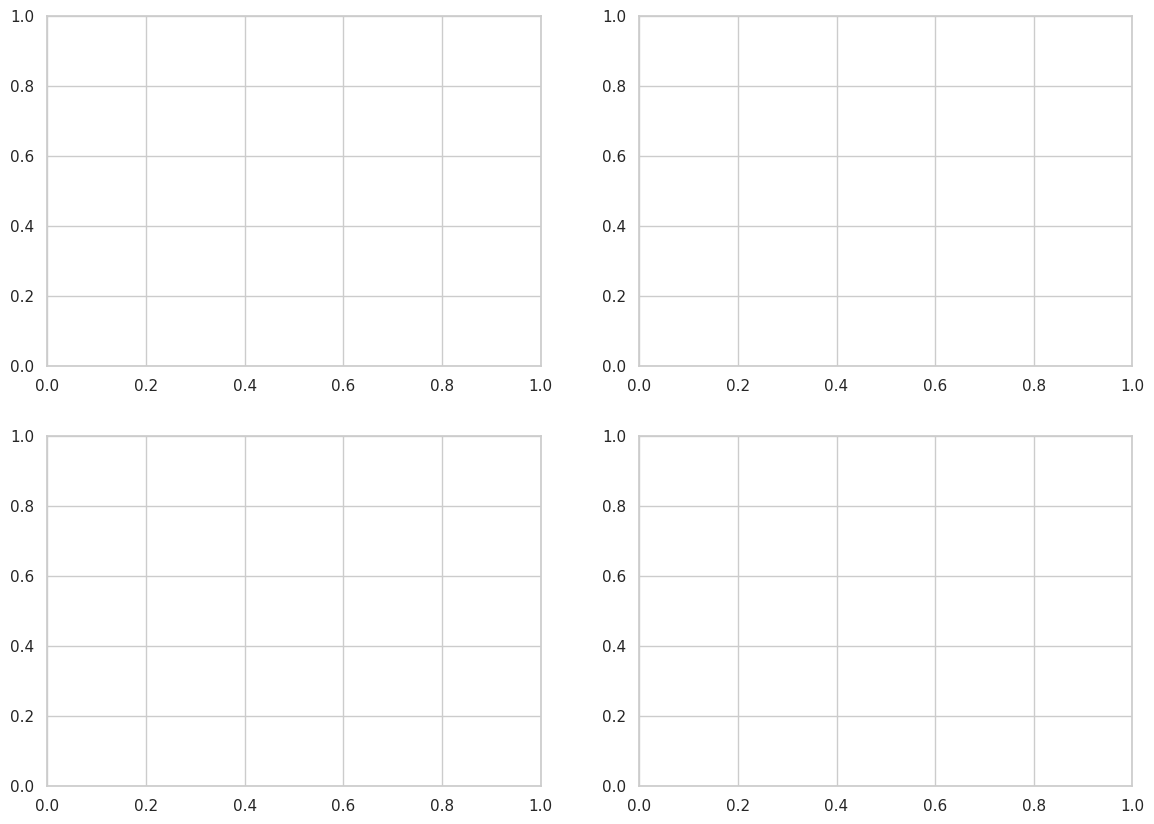

In [52]:
# Set visual style
sns.set_theme(style="whitegrid")
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

In [53]:
# 1. Churn by Contract Type
sns.countplot(data=df, x='Contract', hue='Churn', ax=axes[0, 0], palette='Blues')
axes[0, 0].set_title('Churn Rate by Contract Type')

Text(0.5, 1.0, 'Churn Rate by Contract Type')

In [54]:
# 2. Churn by Internet Service
sns.countplot(data=df, x='InternetService', hue='Churn', ax=axes[0, 1], palette='Oranges')
axes[0, 1].set_title('Churn Rate by Internet Service')

Text(0.5, 1.0, 'Churn Rate by Internet Service')

In [55]:
# 3. Churn by Payment Method
sns.countplot(data=df, x='PaymentMethod', hue='Churn', ax=axes[1, 0], palette='Greens')
axes[1, 0].tick_params(axis='x', rotation=30)
axes[1, 0].set_title('Churn Rate by Payment Method')

Text(0.5, 1.0, 'Churn Rate by Payment Method')

In [56]:
# 4. Tenure Distribution by Churn Status
sns.kdeplot(data=df, x='tenure', hue='Churn', common_norm=False, fill=True, ax=axes[1, 1], palette='Purples')
axes[1, 1].set_title('Tenure Distribution (Months) by Churn')

Text(0.5, 1.0, 'Tenure Distribution (Months) by Churn')

In [57]:
plt.tight_layout()
plt.show()

<Figure size 640x480 with 0 Axes>

In [58]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, roc_auc_score, confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

In [59]:
# 1. Prepare Features (X) and Target (y)
X = df_encoded.drop(columns=['Churn'])
y = df_encoded['Churn']

In [60]:
# 2. Train-Test Split (80% Train, 20% Test)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

In [61]:
# 3. Scale Numerical Features (Tenure, MonthlyCharges, TotalCharges)
scaler = StandardScaler()
X_train_scaled = X_train.copy()
X_test_scaled = X_test.copy()

In [62]:
num_cols = ['tenure', 'MonthlyCharges', 'TotalCharges']
X_train_scaled[num_cols] = scaler.fit_transform(X_train[num_cols])
X_test_scaled[num_cols] = scaler.transform(X_test[num_cols])

In [63]:
# 4. Train Logistic Regression Baseline Model
log_reg = LogisticRegression(max_iter=1000)
log_reg.fit(X_train_scaled, y_train)
y_pred_lr = log_reg.predict(X_test_scaled)
y_prob_lr = log_reg.predict_proba(X_test_scaled)[:, 1]

In [64]:
# 5. Train Random Forest Classifier
rf_model = RandomForestClassifier(n_estimators=100, random_state=42)
rf_model.fit(X_train, y_train)
y_pred_rf = rf_model.predict(X_test)
y_prob_rf = rf_model.predict_proba(X_test)[:, 1]

In [65]:
# 6. Output Model Evaluation Results
print("=== LOGISTIC REGRESSION REPORT ===")
print(classification_report(y_test, y_pred_lr))
print(f"ROC-AUC Score: {roc_auc_score(y_test, y_prob_lr):.4f}\n")

print("=== RANDOM FOREST REPORT ===")
print(classification_report(y_test, y_pred_rf))
print(f"ROC-AUC Score: {roc_auc_score(y_test, y_prob_rf):.4f}")

=== LOGISTIC REGRESSION REPORT ===
              precision    recall  f1-score   support

           0       0.85      0.90      0.87      1035
           1       0.66      0.56      0.60       374

    accuracy                           0.81      1409
   macro avg       0.75      0.73      0.74      1409
weighted avg       0.80      0.81      0.80      1409

ROC-AUC Score: 0.8421

=== RANDOM FOREST REPORT ===
              precision    recall  f1-score   support

           0       0.83      0.90      0.87      1035
           1       0.64      0.49      0.56       374

    accuracy                           0.79      1409
   macro avg       0.74      0.70      0.71      1409
weighted avg       0.78      0.79      0.78      1409

ROC-AUC Score: 0.8278


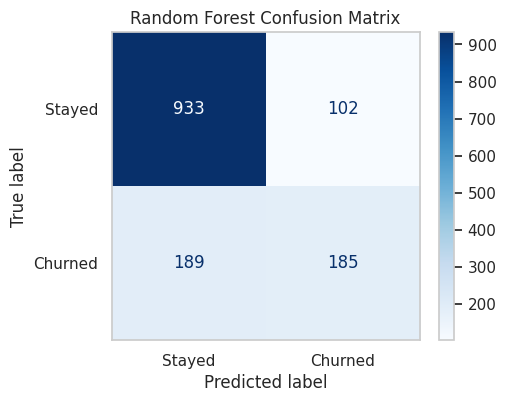

In [66]:
# Plot Confusion Matrix for Random Forest
fig, ax = plt.subplots(figsize=(5, 4))
ConfusionMatrixDisplay.from_predictions(y_test, y_pred_rf, display_labels=['Stayed', 'Churned'], ax=ax, cmap='Blues')
plt.title('Random Forest Confusion Matrix')
plt.grid(False)
plt.show()

In [67]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [68]:
# 1. Feature Importance from Random Forest
importances = rf_model.feature_importances_
feature_names = X.columns
feature_importance_df = pd.DataFrame({'Feature': feature_names, 'Importance': importances})
feature_importance_df = feature_importance_df.sort_values(by='Importance', ascending=False).head(10)

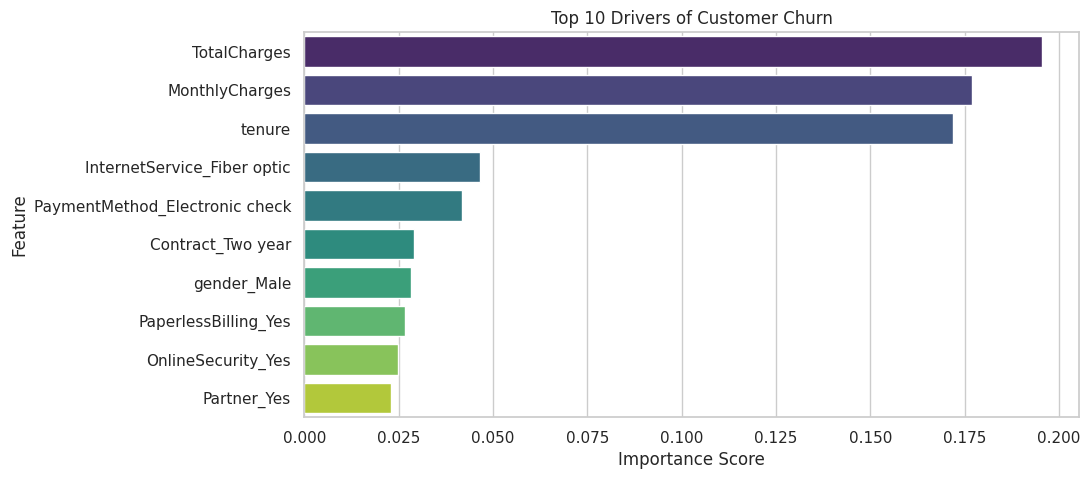

In [69]:
# Modern Seaborn barplot syntax to suppress FutureWarnings
plt.figure(figsize=(10, 5))
sns.barplot(
    data=feature_importance_df,
    x='Importance',
    y='Feature',
    hue='Feature',
    palette='viridis',
    legend=False
)
plt.title('Top 10 Drivers of Customer Churn')
plt.xlabel('Importance Score')
plt.ylabel('Feature')
plt.show()

In [70]:
# 2. Risk Segmentation based on Predicted Probabilities
# Use Random Forest probabilities for test set
test_results = X_test.copy()
test_results['Actual_Churn'] = y_test
test_results['Churn_Probability'] = y_prob_rf

In [71]:
# 2. Risk Segmentation based on Predicted Probabilities
# Use Random Forest probabilities for test set
test_results = X_test.copy()
test_results['Actual_Churn'] = y_test
test_results['Churn_Probability'] = y_prob_rf

# Define Risk Tiers
def assign_risk_tier(prob):
    if prob >= 0.70:
        return 'High Risk'
    elif prob >= 0.35:
        return 'Medium Risk'
    else:
        return 'Low Risk'

test_results['Risk_Tier'] = test_results['Churn_Probability'].apply(assign_risk_tier)

# Summary of Risk Segmentation
print("=== RISK TIER BREAKDOWN ===")
risk_summary = test_results.groupby('Risk_Tier').agg(
    Customer_Count=('Actual_Churn', 'count'),
    Actual_Churners=('Actual_Churn', 'sum'),
    Churn_Rate=('Actual_Churn', 'mean')
).reset_index()

risk_summary['Churn_Rate'] = (risk_summary['Churn_Rate'] * 100).round(2).astype(str) + '%'
display(risk_summary)

=== RISK TIER BREAKDOWN ===


,Risk_Tier,Customer_Count,Actual_Churners,Churn_Rate
0,High Risk,135,99,73.33%
1,Low Risk,938,115,12.26%
2,Medium Risk,336,160,47.62%


In [72]:
%%writefile app.py

Overwriting app.py


In [73]:
!pip install -q streamlit
!npm install localtunnel

⠙⠹⠸⠼⠴⠦
up to date, audited 23 packages in 1s
⠧
⠧3 packages are looking for funding
⠧  run `npm fund` for details
⠧
2 high severity vulnerabilities

To address all issues (including breaking changes), run:
  npm audit fix --force

Run `npm audit` for details.
⠧

In [74]:
%%writefile app.py
import streamlit as st
import pandas as pd
import joblib

st.set_page_config(page_title="Customer Churn Predictor", page_icon="🔮")

st.title("🔮 Telco Customer Churn Predictor")
st.write("Adjust customer attributes to test real-time churn predictions.")

@st.cache_resource
def load_assets():
    model = joblib.load('churn_random_forest_model.pkl')
    scaler = joblib.load('churn_scaler.pkl')
    return model, scaler

model, scaler = load_assets()

# Sidebar Inputs
st.sidebar.header("Customer Profile")
tenure = st.sidebar.slider("Tenure (Months)", 0, 72, 12)
monthly_charges = st.sidebar.number_input("Monthly Charges ($)", value=65.0)
total_charges = st.sidebar.number_input("Total Charges ($)", value=780.0)

contract = st.sidebar.selectbox("Contract Type", ["Month-to-month", "One year", "Two year"])
internet = st.sidebar.selectbox("Internet Service", ["DSL", "Fiber optic", "No"])
payment = st.sidebar.selectbox("Payment Method", ["Electronic check", "Mailed check", "Bank transfer", "Credit card"])

if st.button("Calculate Churn Risk"):
    input_dict = {
        'tenure': tenure,
        'MonthlyCharges': monthly_charges,
        'TotalCharges': total_charges,
        'Contract_One year': 1 if contract == "One year" else 0,
        'Contract_Two year': 1 if contract == "Two year" else 0,
        'InternetService_Fiber optic': 1 if internet == "Fiber optic" else 0,
        'InternetService_No': 1 if internet == "No" else 0,
        'PaymentMethod_Electronic check': 1 if payment == "Electronic check" else 0,
        'PaymentMethod_Mailed check': 1 if payment == "Mailed check" else 0,
        'PaymentMethod_Credit card (automatic)': 1 if payment == "Credit card" else 0,
    }

    input_df = pd.DataFrame([input_dict])

    for col in model.feature_names_in_:
        if col not in input_df.columns:
            input_df[col] = 0

    input_df = input_df[model.feature_names_in_]

    probability = model.predict_proba(input_df)[0][1] * 100

    st.markdown("---")
    st.subheader("Prediction Outcome")
    if probability >= 70:
        st.error(f"⚠️ **High Churn Risk: {probability:.1f}%**\n\nRecommendation: Offer retention incentive immediately.")
    elif probability >= 35:
        st.warning(f"⚡ **Medium Churn Risk: {probability:.1f}%**\n\nRecommendation: Send customer satisfaction survey.")
    else:
        st.success(f"✅ **Low Churn Risk: {probability:.1f}%**\n\nRecommendation: Standard lifecycle communications.")

Overwriting app.py


In [75]:
# 1. Print public IP (Copy this string to use as password)
!curl ipv4.icanhazip.com

35.203.185.78


In [76]:
# 2. Run Streamlit via LocalTunnel
!streamlit run app.py & npx localtunnel --port 8501

⠙⠹

2026-09-01 05:54:21.760 Uvicorn server started on :::8501

  You can now view your Streamlit app in your browser.

  Local URL: http://localhost:8501
  Network URL: http://172.28.0.12:8501
  External URL: http://35.203.185.78:8501

your url is: https://nasty-planes-tell.loca.lt
  Stopping...
^C


In [78]:
import joblib

# Re-save your trained Random Forest model and scaler
joblib.dump(rf_model, 'churn_random_forest_model.pkl')
joblib.dump(scaler, 'churn_scaler.pkl')

print("✅ Model files recreated successfully!")

✅ Model files recreated successfully!


In [79]:
%%writefile requirements.txt
streamlit
pandas
scikit-learn
joblib

Writing requirements.txt


In [80]:
%%writefile app.py
import streamlit as st
import pandas as pd
import joblib
import plotly.express as px

# Page setup
st.set_page_config(page_title="Telco Churn Predictor", page_icon="🔮", layout="wide")

# Load assets
@st.cache_resource
def load_assets():
    model = joblib.load('churn_random_forest_model.pkl')
    scaler = joblib.load('churn_scaler.pkl')
    return model, scaler

model, scaler = load_assets()

# Header
st.title("🔮 Telco Customer Churn Predictor")
st.markdown("Adjust customer profile attributes on the left to evaluate real-time churn probabilities and risk levels.")
st.markdown("---")

# Sidebar inputs
st.sidebar.header("📋 Customer Profile")
tenure = st.sidebar.slider("Tenure (Months)", 0, 72, 12)
monthly_charges = st.sidebar.number_input("Monthly Charges ($)", value=65.00, step=5.0)
total_charges = st.sidebar.number_input("Total Charges ($)", value=780.00, step=50.0)

contract = st.sidebar.selectbox("Contract Type", ["Month-to-month", "One year", "Two year"])
internet = st.sidebar.selectbox("Internet Service", ["DSL", "Fiber optic", "No"])
payment = st.sidebar.selectbox("Payment Method", ["Electronic check", "Mailed check", "Bank transfer (automatic)", "Credit card (automatic)"])

# Prepare input data matching model encoding
# Adjust column encoding names below if your specific model uses one-hot encoding columns
input_data = pd.DataFrame({
    'tenure': [tenure],
    'MonthlyCharges': [monthly_charges],
    'TotalCharges': [total_charges],
    'Contract_One year': [1 if contract == "One year" else 0],
    'Contract_Two year': [1 if contract == "Two year" else 0],
    'InternetService_Fiber optic': [1 if internet == "Fiber optic" else 0],
    'InternetService_No': [1 if internet == "No" else 0],
    'PaymentMethod_Credit card (automatic)': [1 if payment == "Credit card (automatic)" else 0],
    'PaymentMethod_Electronic check': [1 if payment == "Electronic check" else 0],
    'PaymentMethod_Mailed check': [1 if payment == "Mailed check" else 0]
})

# Make prediction
if st.button("🚀 Calculate Churn Risk", type="primary"):
    # Scale numerical features if needed by your scaler, or predict directly
    churn_prob = model.predict_proba(input_data)[0][1]
    churn_percentage = round(churn_prob * 100, 1)

    # Layout into columns
    col1, col2, col3 = st.columns(3)

    with col1:
        st.metric(label="Churn Probability", value=f"{churn_percentage}%")

    with col2:
        if churn_percentage >= 50:
            st.metric(label="Risk Level", value="🔴 High Risk")
        elif churn_percentage >= 25:
            st.metric(label="Risk Level", value="🟡 Medium Risk")
        else:
            st.metric(label="Risk Level", value="🟢 Low Risk")

    with col3:
        annual_val = monthly_charges * 12
        st.metric(label="Est. Annual Value at Risk", value=f"${annual_val:,.2f}")

    # Visual progress bar
    st.write("### Churn Risk Assessment")
    st.progress(int(churn_percentage))

    # Actionable guidance
    if churn_percentage >= 50:
        st.error("⚠️ **Retention Action Required:** High churn probability detected. Recommend targeted discount incentives or contract upgrade offers immediately.")
    elif churn_percentage >= 25:
        st.warning("⚡ **Monitor Customer:** Moderate churn risk. Recommend automated engagement campaigns or service satisfaction check-ins.")
    else:
        st.success("✅ **Healthy Customer:** Low churn risk. Standard lifecycle communications recommended.")

    # Feature Importance visual
    st.markdown("---")
    st.write("### 📊 Top Feature Drivers")

    if hasattr(model, 'feature_importances_'):
        importances = pd.DataFrame({
            'Feature': input_data.columns,
            'Importance': model.feature_importances_
        }).sort_values('Importance', ascending=True)

        fig = px.bar(importances, x='Importance', y='Feature', orientation='h',
                     title="Model Feature Weighting", color='Importance',
                     color_continuous_scale='Blues')
        fig.update_layout(height=350, margin=dict(l=0, r=0, t=30, b=0))
        st.plotly_chart(fig, use_container_width=True)

Overwriting app.py


In [81]:
%%writefile requirements.txt
streamlit
pandas
scikit-learn
joblib
plotly

Overwriting requirements.txt
